# Detecção de Anomalias

A detecção de anomalias é a tarefa de identificar instâncias cujas características diferem significativamente do restante dos dados. Neste notebook, o objetivo é realizar a aplicação de diferentes técnicas de detecção de anomalias usando Python e seus pacotes de bibliotecas.


De forma mais específica, nosso objetivo é detectar mudanças anômalas nos preços de fechamento diários de várias ações. O arquivo de entrada *stocks.csv* contém os preços históricos de fechamento de ações de 3 grandes corporações (Microsoft, Ford Motor Company e Bank of America). 

In [1]:
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [2]:
stocks = pd.read_csv('datasets/stocks.csv', header='infer' ) 
stocks.index = pd.to_datetime(stocks['Date'], format='%m/%d/%Y')
stocks = stocks.drop(['Date'],axis=1)
stocks.head()

,MSFT,F,BAC
Date,,,
2007-01-03,29.860001,7.51,53.330002
2007-01-04,29.809999,7.70,53.669998
2007-01-05,29.639999,7.62,53.240002
2007-01-08,29.930000,7.73,53.450001
2007-01-09,29.959999,7.79,53.500000


Preços absolutos das ações podem não ser adequados para a detecção direta de outliers, porque diferentes ações podem ter escalas muito diferentes de preços. Para uma análise mais informativa, é comum transformar os dados, como por exemplo calcular os retornos diários das ações.

Podemos calcular a variação percentual no preço de fechamento diário de cada ação da seguinte maneira:
\begin{equation}
\Delta(t) = 100 \times \frac{x_t - x_{t-1}}{x_{t-1}} 
\end{equation}

onde $x_t$ denota o preço de uma ação no dia $t$ e $x_{t-1}$ denota o preço no dia anterior, $t-1$.

A função *pct_change()* do Pandas calcula a variação entre um valor anterior e o próximo, porém não em termos percentuais. Para isto, multiplicamos por 100.


In [3]:
delta = stocks.pct_change().dropna()*100
delta.head()

,MSFT,F,BAC
Date,,,
2007-01-04,-0.167455,2.529960,0.637532
2007-01-05,-0.570278,-1.038961,-0.801185
2007-01-08,0.978411,1.443570,0.394438
2007-01-09,0.100231,0.776197,0.093543
2007-01-10,-1.001332,-0.770218,0.149536


Abaixo podemos ver um plot contendo os dados de variação em 3 dimensões. É possível notar que existem alguns dias que diferem bastante em termos de variações em relação aos outros dias. Talvez possam ser considerados dias anômalos do mercado.

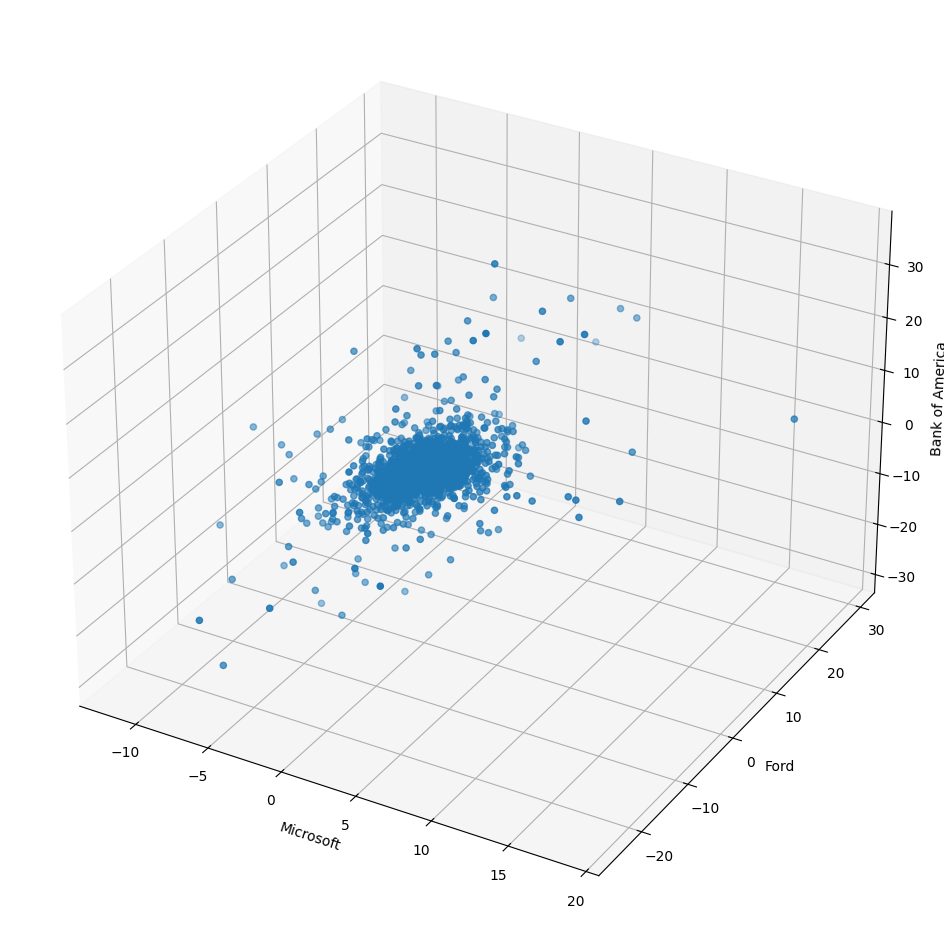

In [4]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(delta.MSFT,delta.F,delta.BAC)
ax.set_xlabel('Microsoft')
ax.set_ylabel('Ford')
ax.set_zlabel('Bank of America')
plt.show()

## Abordagens Estatísticas para Detecção de Anomalias 

Abordagens estatísticas para detecção de anomalias partem de pressupostos sobre a normalidade dos dados. Em geral, assumem que os objetos normais no dataset são gerados por um modelo gerador. Sendo assim, objetos normais ocorrem em regões de alta probabilidade do modelo, enquanto anomalias ocorrem em regiões de baixa probabilidade. A ideia geral de abordagens estatísticas é aprender um modelo que se ajuste aos dados e identificar os objetos nas regiões de baixa probabilidade.

Métodos estatísticos para detecção de anomalias podem ser divididos em dois tipos:
- Métodos paramétricos: assumem que os dados são gerados por uma distribuição paramétrica com um número finito de parâmetros Θ. A função de densidade de probabilidade da distribuição paramétrica 𝑓(𝑥,Θ) dá a probabilidade do objeto 𝑥 ser gerado pela distribuição. Sendo assim, quanto menor o valor, maior chance de 𝑥 ser anomalia.

- Não-paramétrico: não assumem um modelo estatístico a priori com um número finito de parâmetros. Tentam determinar o modelo a partir dos dados de entrada sem tentar determinar os parâmetros da função geradora (o que não necessariamente significa que o modelo não tenha parâmetros). Geralmente assumem que o número e a natureza dos parâmetros é flexível e não fixa.


### Métodos Paramétricos

Um dos métodos mais tradicionais e simples para detecção estatística de anomalias é o método da máxima verossimilhança. Neste método, calculamos a média $𝜇$ e o desvio padrão $\sigma$ da nossa variável e depois utilizamos algum critério para avaliar os outliers com base nesses valores. Um critério bastante utilizado é o critério dos 3 $\sigma$, onde outliers são aqueles que estão a mais de 3 desvioes padrão da média.

Um segundo método bastante simples é o método do boxplot, onde plotamos nossos dados em um boxplot e consideramos como outliers aqueles objetos que se encontram fora do intervalo $1.5*IQR$.

### Exercício 1
Encontre os outliers para o dataset da variação percentual do preço das ações utilizando 1) Método da verossimilhança; 2) Método do boxplot. 

Os outliers encontrados são os mesmos?

In [ ]:
#verossimilhança

delta = stocks[['MSFT', 'F', 'BAC']].pct_change().dropna() * 100

media = delta.mean()
desvio = delta.std()
outliers_verossimilhanca = (abs(delta - media) > 3 * desvio)
outliers_verossimilhanca.sum()

MSFT    44
F       39
BAC     52
dtype: int64

In [ ]:
#boxplot

# Quartis e IQR
Q1 = delta.quantile(0.25)
Q3 = delta.quantile(0.75)
IQR = Q3 - Q1

# Critério do boxplot
outliers_boxplot = (delta < (Q1 - 1.5 * IQR)) | (delta > (Q3 + 1.5 * IQR))
outliers_boxplot.sum()

MSFT    139
F       183
BAC     222
dtype: int64

### Métodos Não-Paramétricos

Métodos não-paramétricos para detecção de anomalias utilizam os dados de entrada para modelar o que são os “dados normais”. Em geral, este tipo de método não realiza tantos pressupostos sobre os dados, e, por isto, podem ser aplicados em mais cenários.

Dois métodos não paramétricos bastante utilizados são o método do Histograma e o método da Estimativa de Densidade Kernel. No método do histograma, dividimos nossos dados em bins e verificar quais objetos caem dentro dos bins (ou pelo menos dentro dos bins mais frequentes). Os objetos que pertencem a nenhum bin ou estão em bins de frequência muito baixa são considerados anomalias. Já para a Estimativa de Densidade Kernel, utilizamos uma função kernel (geralmente o Kernel Gaussiano) para suavizar nossos dados e investigar quais objetos ficam fora do comportamento esperado dos dados.


### Exercício 2

Encontre os outliers para o dataset da variação percentual do preço das ações utilizando 1) Método do Histograma; 2) Método da Estimativa de Densidade Kernel.

Utilize a classe **KernelDensity** da bilbioteca **scikit-learn** para o cálculo dos scores na EDK.

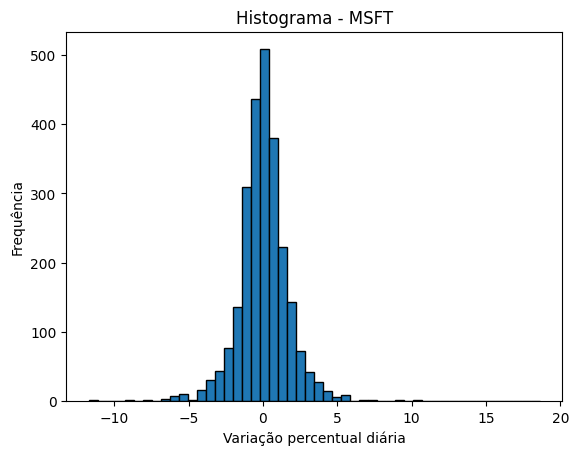

In [ ]:
#histograma

import matplotlib.pyplot as plt

serie = delta['MSFT']

plt.hist(serie, bins=50, edgecolor='black')
plt.title("Histograma - MSFT")
plt.xlabel("Variação percentual diária")
plt.ylabel("Frequência")
plt.show()

In [ ]:
#EDK

from sklearn.neighbors import KernelDensity
import numpy as np

X = delta['MSFT'].values.reshape(-1, 1)
kde = KernelDensity(kernel='gaussian', bandwidth=1.0).fit(X)

log_density = kde.score_samples(X)
limiar = np.percentile(log_density, 1)

outliers_edk = log_density < limiar

print("Outliers detectados via EDK:", outliers_edk.sum())

Outliers detectados via EDK: 26


## Abordagens Baseadas em Clustering para Detecção de Anomalias 

Clustering tem o objetivo de encontrar objetos fortemente relacionados, enquanto detecção de anomalias tem o objetivo de encontrar objetos que não são relacionados com outros. Não é surpresa que estas tarefas estejam fortemente relacionadas! Uma definição simples para uma anomalia baseada em cluster é: “Um objeto é um *cluster-based outlier* se não pertence fortemente a nenhum cluster”.

Uma forma de encontrar outliers utilizando abordagens baseadas em clustering é aplicar o algoritmo K-Means para separar os dados e, após isto, calcular a distância de cada objeto até o centróide mais próximos. Depois calculamos a média de distância média dos objetos ao seu centróide para da cada cluster. O razão entre a distância do objeto para seu cluster mais próximos sobre a distância média de cada cluster resulta em um score relativo que pode ser utilizado para definir se um objeto é um outlier ou não. Quanto maior o score, maior a probabilidade de um outlier.


### Exercício 3
Utilize o algoritmo K-Means para detectar outliers no dataset da variação percentual do preço das ações. Calcule um score de "outlierness" conforme mencionado acima e utilize a função *plot_score()* abaixo para plotar os dados considerando este score. A função espera um vetor **anomaly_score** com o mesmo número de instâncias do que o dataset *delta*, contendo o score de anomalia para cada dia.

In [9]:
def plot_score(anomaly_score):
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111, projection='3d')
    p = ax.scatter(delta.MSFT,delta.F,delta.BAC,c=anomaly_score,cmap='jet')
    ax.set_xlabel('Microsoft')
    ax.set_ylabel('Ford')
    ax.set_zlabel('Bank of America')
    fig.colorbar(p)
    plt.show()

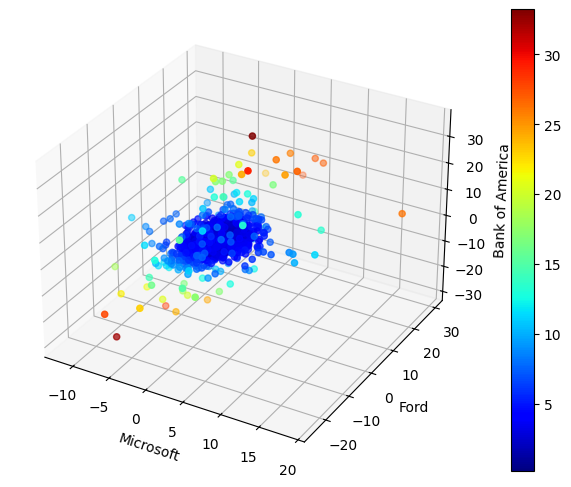

In [ ]:
#k-means

from sklearn.cluster import KMeans
from numpy.linalg import norm

kmeans = KMeans(n_clusters=2, random_state=0).fit(delta)

distancias = norm(delta.values - kmeans.cluster_centers_[kmeans.labels_], axis=1)
anomaly_score = distancias

plot_score(anomaly_score)